In [2]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
acc=pd.read_csv("../data/raw/accounts.csv")
churn_ev=pd.read_csv("../data/raw/churn_events.csv")
feature=pd.read_csv("../data/raw/feature_usage.csv")
subs=pd.read_csv("../data/raw/subscriptions.csv")
sup_tkt=pd.read_csv("../data/raw/support_tickets.csv")


In [14]:
print("accounts: ", acc.shape)
print("churn events : ", churn_ev.shape)
print("feature usage : ", feature.shape)
print("subscriptions : ", subs.shape)
print("support ticket : ", sup_tkt.shape)

accounts:  (500, 10)
churn events :  (600, 9)
feature usage :  (25000, 8)
subscriptions :  (5000, 14)
support ticket :  (2000, 9)


In [10]:
print("ACCOUNTS")
print(acc.info())
print()

print("CHURN EVENTS")
print(churn_ev.info())
print()

print("FEATURE USAGE")
print(feature.info())
print()

print("SUBSCRIPTIONS")
print(subs.info())
print()

print("SUPPORT TICKETS")
print(sup_tkt.info())
print()


ACCOUNTS
<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   account_id       500 non-null    str  
 1   account_name     500 non-null    str  
 2   industry         500 non-null    str  
 3   country          500 non-null    str  
 4   signup_date      500 non-null    str  
 5   referral_source  500 non-null    str  
 6   plan_tier        500 non-null    str  
 7   seats            500 non-null    int64
 8   is_trial         500 non-null    bool 
 9   churn_flag       500 non-null    bool 
dtypes: bool(2), int64(1), str(7)
memory usage: 32.4 KB
None

CHURN EVENTS
<class 'pandas.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   churn_event_id            600 non-null    str    
 1   account_id                600 n

1. One account has more than one subscription and feature usage i.e we will have to aggregate it.
2. churn events > accounts, this indicates some accounts had dropped out and renewed again.
3. All dates are in string i need to convert them to date type.
4. Missing data in feedback text, end date (in subscription) and satisfaction score.
5. All tables connected via account id only usage table connected via subscription id.

In [15]:
print("ACCOUNTS")
print(acc.describe())
print()

print("CHURN EVENTS")
print(churn_ev.describe())
print()

print("FEATURE USAGE")
print(feature.describe())
print()

print("SUBSCRIPTIONS")
print(subs.describe())
print()

print("SUPPORT TICKETS")
print(sup_tkt.describe())
print()

ACCOUNTS
            seats
count  500.000000
mean    20.560000
std     21.044718
min      1.000000
25%      5.000000
50%     15.000000
75%     28.000000
max    163.000000

CHURN EVENTS
       refund_amount_usd
count         600.000000
mean           14.420417
std            39.224591
min             0.000000
25%             0.000000
50%             0.000000
75%             0.000000
max           392.920000

FEATURE USAGE
        usage_count  usage_duration_secs   error_count
count  25000.000000         25000.000000  25000.000000
mean      10.021000          3042.202880      0.564280
std        3.143729          2056.544615      1.012595
min        0.000000             0.000000      0.000000
25%        8.000000          1350.000000      0.000000
50%       10.000000          2760.000000      0.000000
75%       12.000000          4400.000000      1.000000
max       26.000000         12696.000000      8.000000

SUBSCRIPTIONS
             seats    mrr_amount     arr_amount
count  5000.00000

In [4]:
# AGRREGATE AND JOIN

# Subscriptions → one row per account 
subs_agg = subs.groupby('account_id').agg(
    max_mrr            = ('mrr_amount',      'max'),
    mean_mrr           = ('mrr_amount',      'mean'),
    total_seats_sub    = ('seats',           'max'),
    sub_count          = ('subscription_id', 'count'),
    ever_upgraded      = ('upgrade_flag',    'max'),
    ever_downgraded    = ('downgrade_flag',  'max'),
    auto_renew         = ('auto_renew_flag', 'max'),
    billing_frequency  = ('billing_frequency','first'),   # take most recent
    plan_tier_sub      = ('plan_tier',       'last'),
).reset_index()

# Support tickets → one row per account 
tickets_agg = sup_tkt.groupby('account_id').agg(
    ticket_count          = ('ticket_id',                    'count'),
    mean_resolution_hrs   = ('resolution_time_hours',        'mean'),
    mean_first_response   = ('first_response_time_minutes',  'mean'),
    mean_satisfaction     = ('satisfaction_score',           'mean'),
    escalation_count      = ('escalation_flag',              'sum'),
).reset_index()

# Feature usage → sub_id first, then account_id , CAUSE SUB_ID IS THE FOREIGN KEY
usage_sub = feature.groupby('subscription_id').agg(
    total_usage_count    = ('usage_count',          'sum'),
    total_usage_duration = ('usage_duration_secs',  'sum'),
    total_errors         = ('error_count',          'sum'),
    distinct_features    = ('feature_name',         'nunique'),
    beta_feature_usage   = ('is_beta_feature',      'sum'),
).reset_index()

# now bridge usage → account via subscriptions table
usage_bridge = subs[['subscription_id','account_id']].drop_duplicates()
usage_sub    = usage_sub.merge(usage_bridge, on='subscription_id', how='left')

usage_agg = usage_sub.groupby('account_id').agg(
    total_usage_count    = ('total_usage_count',    'sum'),
    total_usage_duration = ('total_usage_duration', 'sum'),
    total_errors         = ('total_errors',         'sum'),
    distinct_features    = ('distinct_features',    'max'),
    beta_feature_usage   = ('beta_feature_usage',   'sum'),
).reset_index()

# Churn events → one row per account 
churn_agg = churn_ev.groupby('account_id').agg(
    churn_event_count        = ('churn_event_id',           'count'),
    total_refund             = ('refund_amount_usd',        'sum'),
    ever_reactivated         = ('is_reactivation',          'max'),
    preceding_downgrade      = ('preceding_downgrade_flag', 'max'),
    preceding_upgrade        = ('preceding_upgrade_flag',   'max'),
    most_recent_reason       = ('reason_code',              'last'),
).reset_index()

# Left join everything onto accounts
df = acc.copy()
df = df.merge(subs_agg,    on='account_id', how='left')
df = df.merge(tickets_agg, on='account_id', how='left')
df = df.merge(usage_agg,   on='account_id', how='left')
df = df.merge(churn_agg,   on='account_id', how='left')

print("Final shape:", df.shape)          # must be (500, ~40)
print("Columns:\n", df.columns.tolist())
df.head(3)

Final shape: (500, 35)
Columns:
 ['account_id', 'account_name', 'industry', 'country', 'signup_date', 'referral_source', 'plan_tier', 'seats', 'is_trial', 'churn_flag', 'max_mrr', 'mean_mrr', 'total_seats_sub', 'sub_count', 'ever_upgraded', 'ever_downgraded', 'auto_renew', 'billing_frequency', 'plan_tier_sub', 'ticket_count', 'mean_resolution_hrs', 'mean_first_response', 'mean_satisfaction', 'escalation_count', 'total_usage_count', 'total_usage_duration', 'total_errors', 'distinct_features', 'beta_feature_usage', 'churn_event_count', 'total_refund', 'ever_reactivated', 'preceding_downgrade', 'preceding_upgrade', 'most_recent_reason']


,account_id,account_name,industry,country,signup_date,referral_source,plan_tier,seats,is_trial,churn_flag,...,total_usage_duration,total_errors,distinct_features,beta_feature_usage,churn_event_count,total_refund,ever_reactivated,preceding_downgrade,preceding_upgrade,most_recent_reason
0,A-2e4581,Company_0,EdTech,US,2024-10-16,partner,Basic,9,False,False,...,152339,38,8,4,2.0,0.00,False,False,True,competitor
1,A-43a9e3,Company_1,FinTech,IN,2023-08-17,other,Basic,18,False,True,...,101136,14,8,2,NaN,NaN,NaN,NaN,NaN,NaN
2,A-0a282f,Company_2,DevTools,US,2024-08-27,organic,Basic,1,False,False,...,251210,48,10,5,2.0,62.66,False,True,False,support


In [5]:

# counts + proportions
print(df['churn_flag'].value_counts())
print("\nProportions:")
print(df['churn_flag'].value_counts(normalize=True).round(3))



churn_flag
False    390
True     110
Name: count, dtype: int64

Proportions:
churn_flag
False    0.78
True     0.22
Name: proportion, dtype: float64


IT IS IMBALANCED DATA 
HAVE TO TREAD CAREFULLY WITH MACRO F1 SCORE 

                     missing_count  missing_pct
churn_event_count              148         29.6
total_refund                   148         29.6
ever_reactivated               148         29.6
preceding_downgrade            148         29.6
preceding_upgrade              148         29.6
most_recent_reason             148         29.6
mean_satisfaction               34          6.8
ticket_count                     8          1.6
mean_resolution_hrs              8          1.6
mean_first_response              8          1.6
escalation_count                 8          1.6


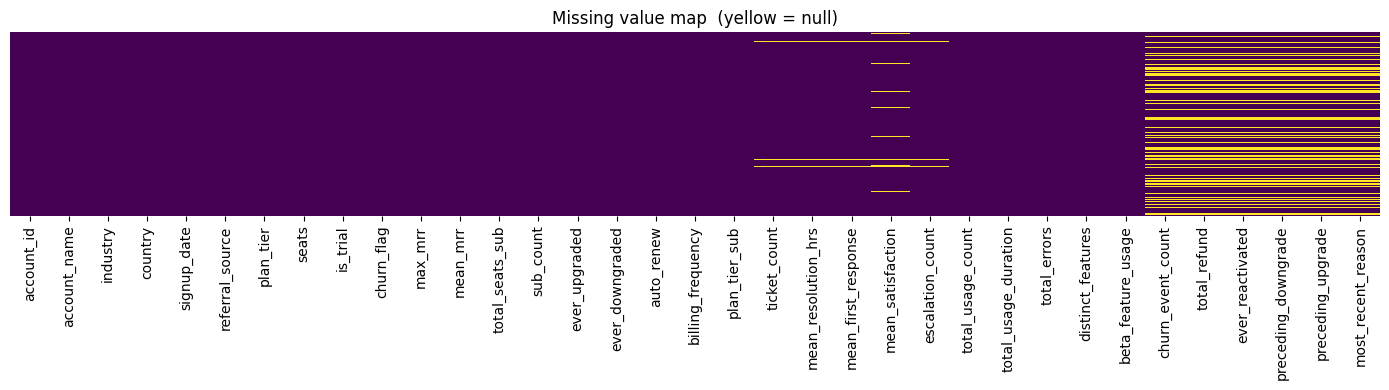

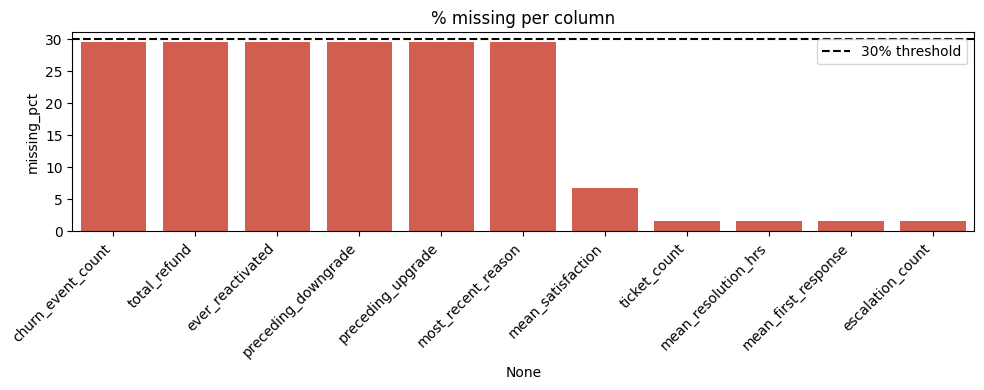


Nulls after fix: 592


In [6]:
# ── BLOCK 5 : Missing Values ─────────────────────────────────────────────────

# table view
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_df = pd.DataFrame({'missing_count': missing,
                            'missing_pct':  missing_pct})
missing_df = missing_df[missing_df['missing_count'] > 0].sort_values('missing_pct', ascending=False)
print(missing_df)

# heatmap — works best when there are nulls to show
plt.figure(figsize=(14, 4))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Missing value map  (yellow = null)')
plt.tight_layout()
plt.savefig('../data/external/missing_values.png', dpi=150)
plt.show()

# bar chart of % missing per column
if not missing_df.empty:
    plt.figure(figsize=(10, 4))
    sns.barplot(x=missing_df.index, y='missing_pct', data=missing_df, color='#e74c3c')
    plt.axhline(30, color='black', linestyle='--', label='30% threshold')
    plt.xticks(rotation=45, ha='right')
    plt.title('% missing per column')
    plt.legend()
    plt.tight_layout()
    plt.show()

# fix satisfaction_score specifically
df['has_satisfaction_score'] = df['mean_satisfaction'].notna().astype(int)
df['mean_satisfaction']      = df['mean_satisfaction'].fillna(df['mean_satisfaction'].median())

# fill numeric nulls from left-join gaps (accounts with no tickets/usage)
numeric_cols = df.select_dtypes(include='number').columns
df[numeric_cols] = df[numeric_cols].fillna(0)

print("\nNulls after fix:", df.isnull().sum().sum())

In [7]:
# ── Diagnose remaining nulls ─────────────────────────────────────────────────

null_report = df.isnull().sum()
null_report = null_report[null_report > 0].sort_values(ascending=False)

print("Columns still having nulls:")
print(null_report)
print("\nTotal null cells:", df.isnull().sum().sum())
print("\nDtypes of null columns:")
print(df[null_report.index].dtypes)

Columns still having nulls:
ever_reactivated       148
preceding_downgrade    148
preceding_upgrade      148
most_recent_reason     148
dtype: int64

Total null cells: 592

Dtypes of null columns:
ever_reactivated       object
preceding_downgrade    object
preceding_upgrade      object
most_recent_reason        str
dtype: object


In [17]:
obj_cols = df.select_dtypes(include='object').columns
df[obj_cols] = df[obj_cols].fillna('unknown')

# final check
print("Nulls remaining:", df.isnull().sum().sum())   # must be 0
print("Shape:", df.shape)

Nulls remaining: 0
Shape: (500, 36)


/var/folders/1f/s5ng3yhj5h74vy22_8nhx_mh0000gn/T/ipykernel_19166/1322660816.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  obj_cols = df.select_dtypes(include='object').columns


In [ ]:
df['most_recent_reason'] = df['most_recent_reason'].replace('Unknown', 'unknown')

# because i could notice there were two types of unkowns so to remove the discrepancy and converted it to one itself 

/var/folders/1f/s5ng3yhj5h74vy22_8nhx_mh0000gn/T/ipykernel_19166/382995078.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=churn_by_cat, x=col, y='churn_rate_pct',
/var/folders/1f/s5ng3yhj5h74vy22_8nhx_mh0000gn/T/ipykernel_19166/382995078.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=churn_by_cat, x=col, y='churn_rate_pct',
/var/folders/1f/s5ng3yhj5h74vy22_8nhx_mh0000gn/T/ipykernel_19166/382995078.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=churn_by_cat, x=col, y='churn_rate_pct',
/var/folders/1f/s5ng3yhj5

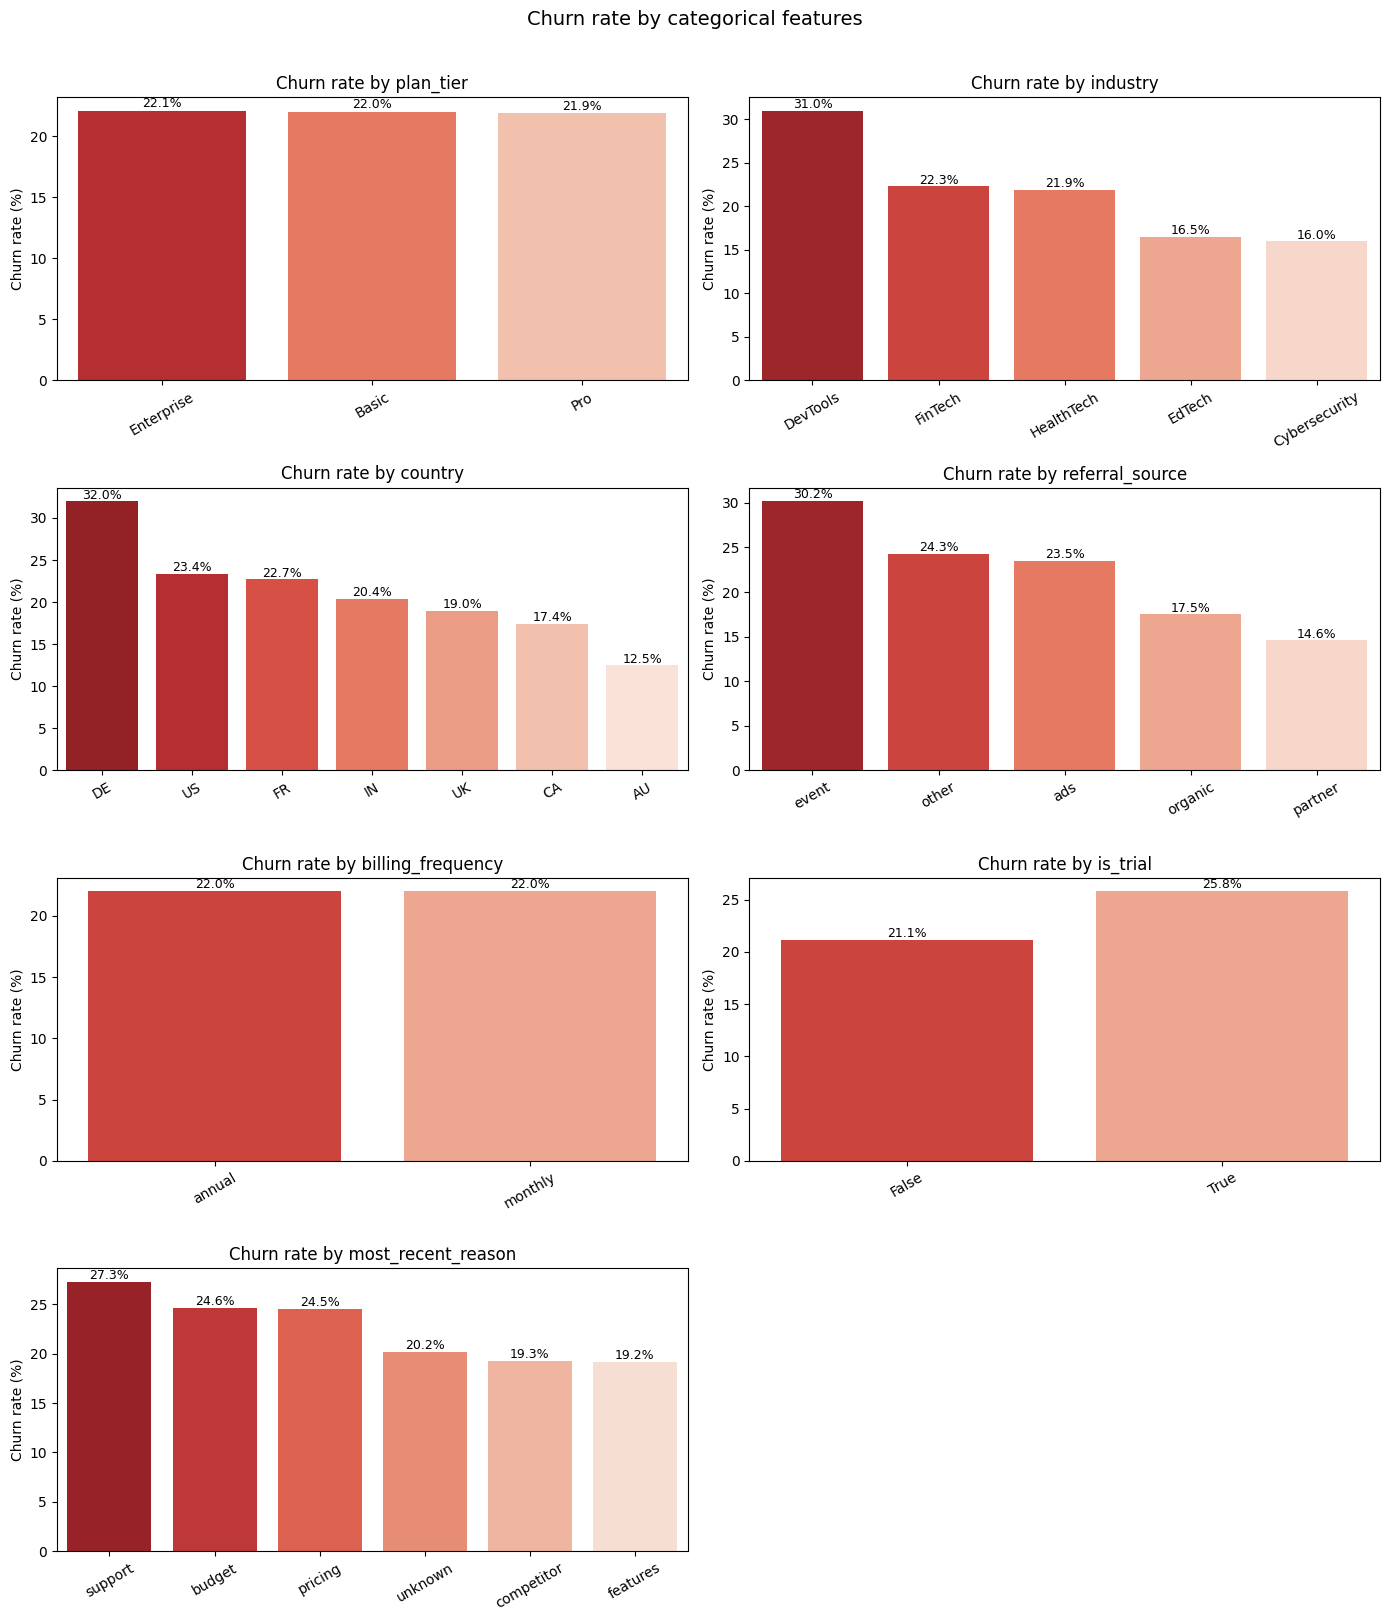

In [20]:
# ── BLOCK 6 : Churn Rate by Category ────────────────────────────────────────

cat_cols = ['plan_tier', 'industry', 'country', 'referral_source',
            'billing_frequency', 'is_trial', 'most_recent_reason']

# filter to only those that actually exist in df after merges
cat_cols = [c for c in cat_cols if c in df.columns]

n = len(cat_cols)
fig, axes = plt.subplots(nrows=(n+1)//2, ncols=2, figsize=(14, 4 * ((n+1)//2)))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    churn_by_cat = (df.groupby(col)['churn_flag']
                      .mean()
                      .mul(100)
                      .round(1)
                      .sort_values(ascending=False)
                      .reset_index())
    churn_by_cat.columns = [col, 'churn_rate_pct']

    sns.barplot(data=churn_by_cat, x=col, y='churn_rate_pct',
                palette='Reds_r', ax=axes[i])
    axes[i].set_title(f'Churn rate by {col}')
    axes[i].set_ylabel('Churn rate (%)')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=30)
    for p in axes[i].patches:
        axes[i].annotate(f"{p.get_height():.1f}%",
                         (p.get_x() + p.get_width()/2, p.get_height() + 0.3),
                         ha='center', fontsize=9)

# hide any unused subplots
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Churn rate by categorical features', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../data/external/churn_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

1. trial accounts have greater churn rate than the ones who are alreday subscribed 
2. australia and canada have the lowest churn rate
3. ads other and event ref source give hight churning probably due to false marketing
4. devtools fintech and healthcare industries have more churn rate (extra crucial fields - continues changing of tools)
5. lack of support and expensiveness are the main cause for customers leaving.

WHAT NEEDS TO BE FIXED -
1. Costing
2. Support system 
3. Product quality in trial rounds
4. Marketing strategy
5. Industry based personalised package?

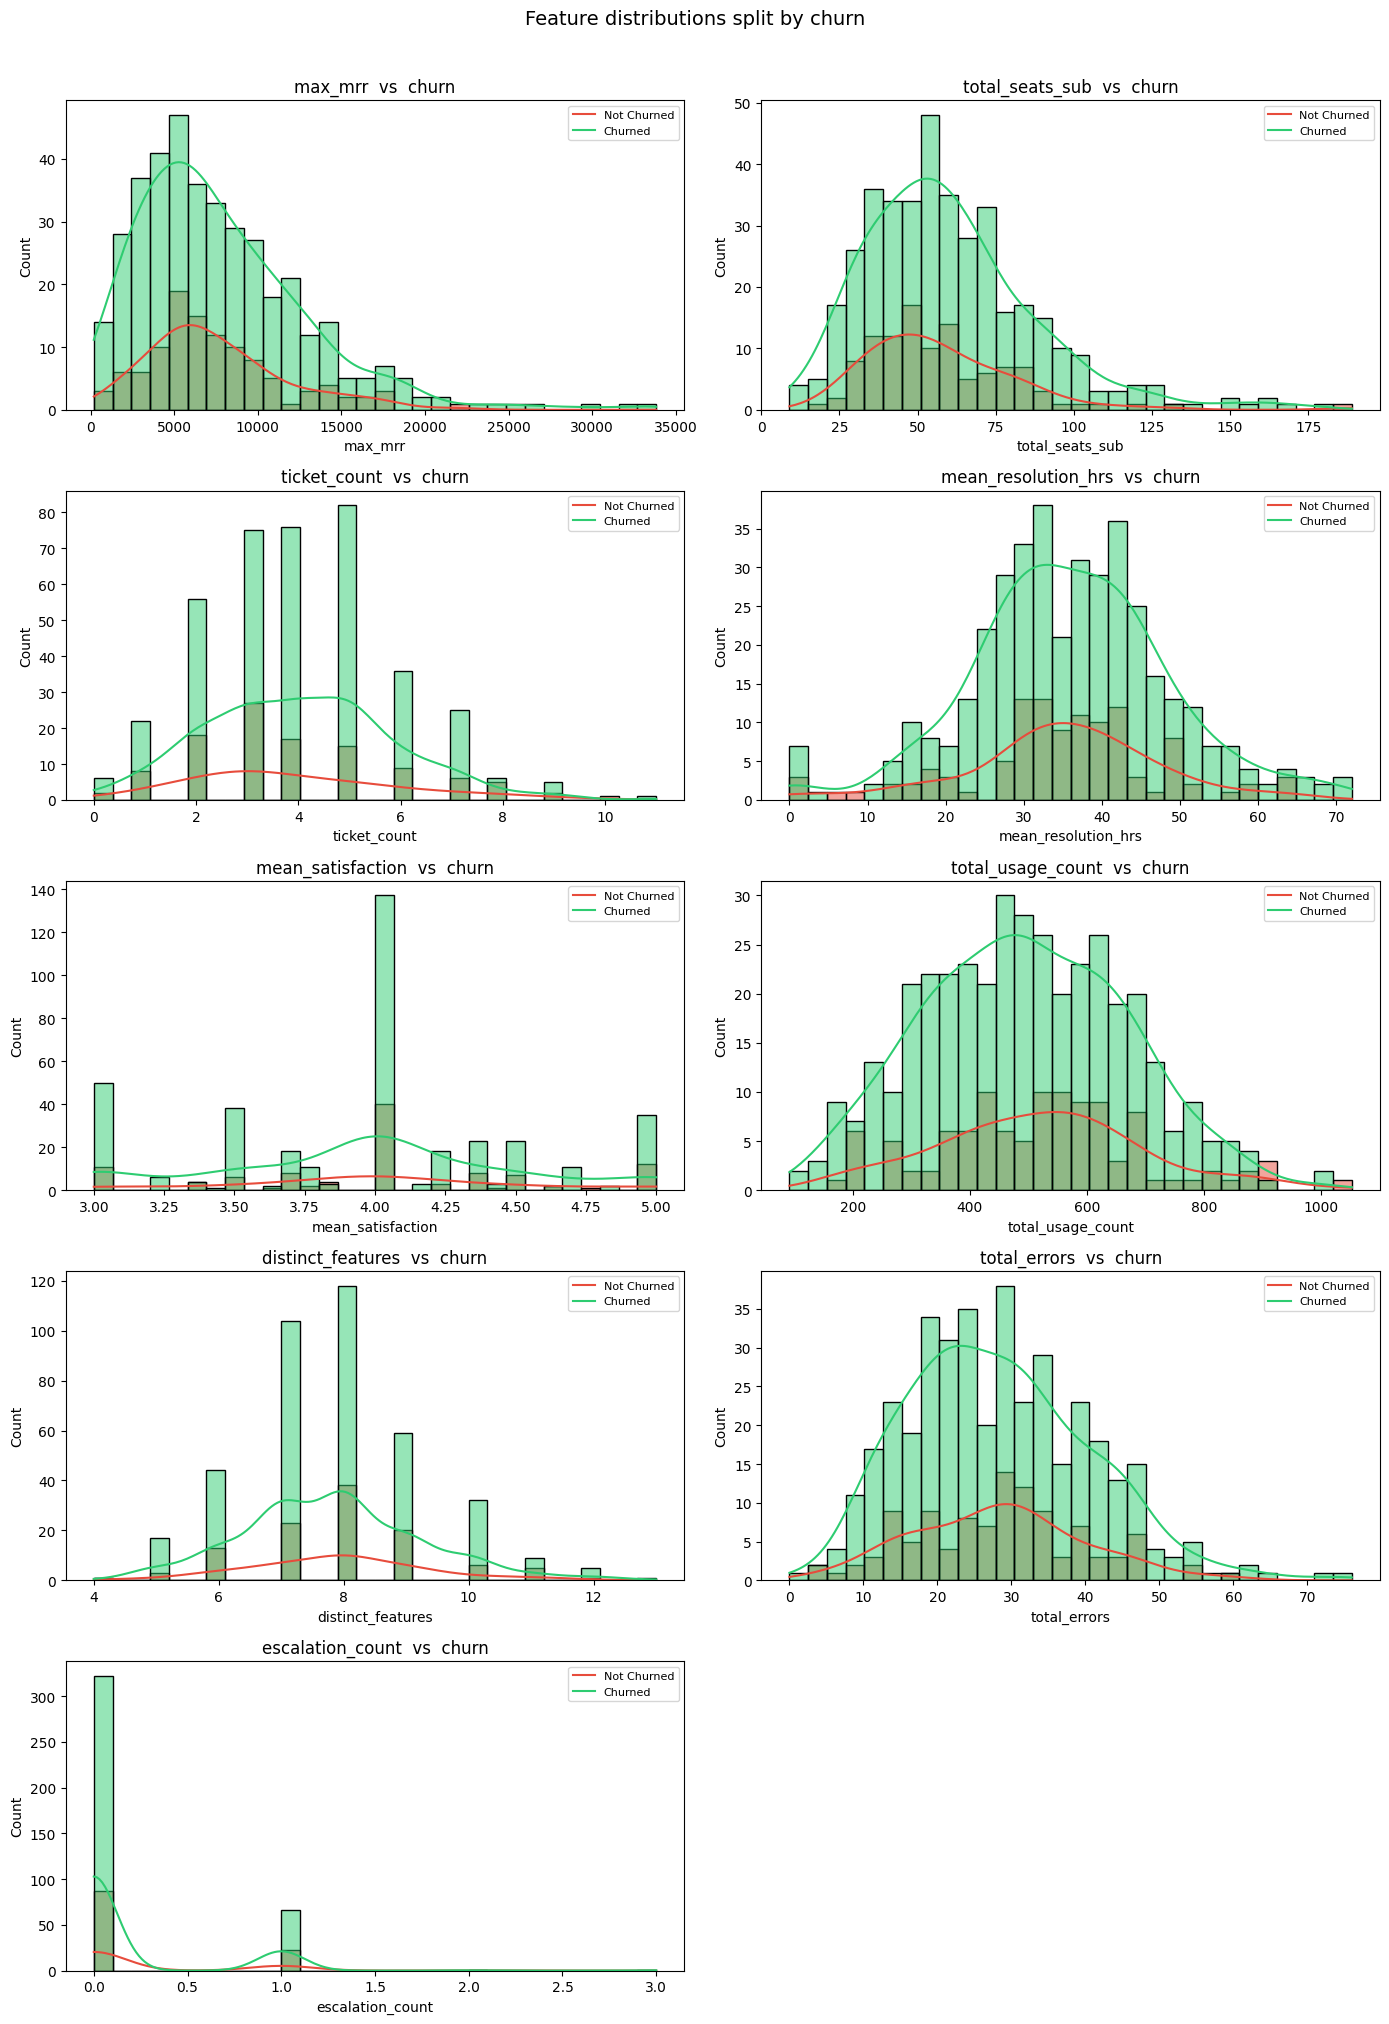

In [21]:
# ── BLOCK 7 : Numerical Distributions vs Churn ──────────────────────────────

num_cols = ['max_mrr', 'total_seats_sub', 'ticket_count',
            'mean_resolution_hrs', 'mean_satisfaction',
            'total_usage_count', 'distinct_features',
            'total_errors', 'escalation_count']

# filter to cols that exist
num_cols = [c for c in num_cols if c in df.columns]

n = len(num_cols)
fig, axes = plt.subplots(nrows=(n+1)//2, ncols=2, figsize=(14, 4 * ((n+1)//2)))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(data=df, x=col, hue='churn_flag',
                 kde=True, bins=30, palette={False:'#2ecc71', True:'#e74c3c'},
                 alpha=0.5, ax=axes[i])
    axes[i].set_title(f'{col}  vs  churn')
    axes[i].set_xlabel(col)
    axes[i].legend(labels=['Not Churned','Churned'], fontsize=8)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Feature distributions split by churn', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../data/external/distributions.png', dpi=150, bbox_inches='tight')
plt.show()

- STRONG OVERLAP - WEAK FEATURES 
- CLEAR DISTINCTION - STRONG FEATURES

- STRONG FEATURES:
1. mean satisfaction 
2. distinct features 
3. escalation count 
4. total usage count 
5. total errors (mid)
6. ticket count (mid)
7. total seats sub (mid)


- WEAK FEATURES
1. max mmr
2. mean res hours


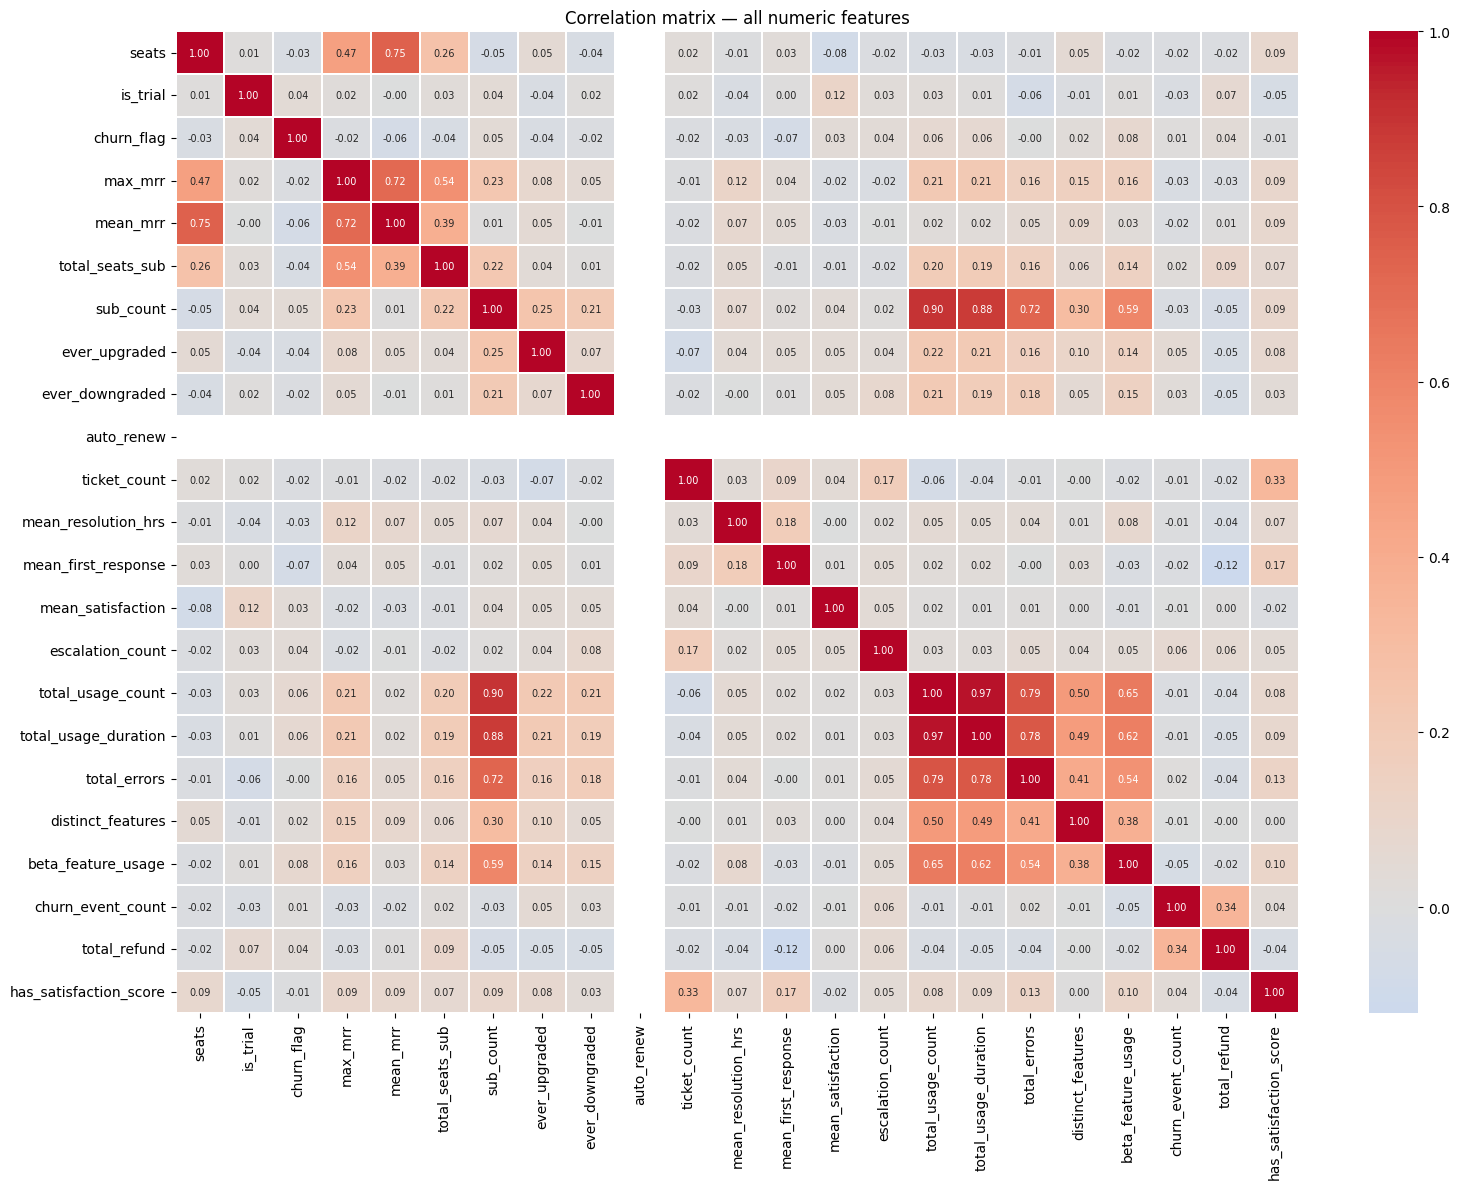


Top correlations with churn_flag:
beta_feature_usage      0.076595
mean_first_response     0.066934
total_usage_count       0.064186
total_usage_duration    0.063095
mean_mrr                0.060208
sub_count               0.047275
is_trial                0.044687
total_seats_sub         0.041522
total_refund            0.038372
escalation_count        0.035891
Name: churn_flag, dtype: float64

Highly correlated feature PAIRS (|r| > 0.85):
total_usage_count     total_usage_duration    0.973483
sub_count             total_usage_count       0.903213
total_usage_duration  sub_count               0.878153
dtype: float64


In [ ]:
# Correlation Matrix 

# select numerics + convert booleans to int for correlation
bool_cols = df.select_dtypes(include='bool').columns.tolist()
df_corr   = df.copy()
df_corr[bool_cols] = df_corr[bool_cols].astype(int)

numeric_df = df_corr.select_dtypes(include='number')

# drop identifiers that snuck in
drop_ids = [c for c in numeric_df.columns if 'id' in c.lower()]
numeric_df = numeric_df.drop(columns=drop_ids, errors='ignore')

corr_matrix = numeric_df.corr()

plt.figure(figsize=(16, 12))
mask = corr_matrix.abs() < 0.05          # hide very weak correlations
sns.heatmap(corr_matrix,
            annot=True, fmt='.2f',
            cmap='coolwarm', center=0,
            linewidths=0.3,
            annot_kws={'size': 7})
plt.title('Correlation matrix — all numeric features')
plt.tight_layout()
plt.savefig('../data/external/correlation_matrix.png', dpi=150)
plt.show()

# print top correlates with target
print("\nTop correlations with churn_flag:")
print(corr_matrix['churn_flag']
      .drop('churn_flag')
      .abs()
      .sort_values(ascending=False)
      .head(10))

# flag multicollinearity
print("\nHighly correlated feature PAIRS (|r| > 0.85):")
corr_pairs = (corr_matrix.abs()
               .unstack()
               .sort_values(ascending=False)
               .drop_duplicates())
corr_pairs = corr_pairs[(corr_pairs > 0.85) & (corr_pairs < 1.0)]
print(corr_pairs.head(10))

non linear relations of features with label

In [23]:

# save processed master dataframe
df.to_csv('../data/processed/master_df.csv', index=False)
print("master_df saved →  data/processed/master_df.csv")
print("Shape:", df.shape)
print("Churn rate:", df['churn_flag'].mean().round(3))
print("Columns:", df.columns.tolist())

master_df saved →  data/processed/master_df.csv
Shape: (500, 36)
Churn rate: 0.22
Columns: ['account_id', 'account_name', 'industry', 'country', 'signup_date', 'referral_source', 'plan_tier', 'seats', 'is_trial', 'churn_flag', 'max_mrr', 'mean_mrr', 'total_seats_sub', 'sub_count', 'ever_upgraded', 'ever_downgraded', 'auto_renew', 'billing_frequency', 'plan_tier_sub', 'ticket_count', 'mean_resolution_hrs', 'mean_first_response', 'mean_satisfaction', 'escalation_count', 'total_usage_count', 'total_usage_duration', 'total_errors', 'distinct_features', 'beta_feature_usage', 'churn_event_count', 'total_refund', 'ever_reactivated', 'preceding_downgrade', 'preceding_upgrade', 'most_recent_reason', 'has_satisfaction_score']
